# 1D Viscous Burgers Equation Simulation

## Import Library

In [9]:
import numpy as np
import matplotlib.pyplot as plt

## Setup the Domain

In [10]:
L = 4   # Length of the domain
N = 400 # Number of grid points (increased for better resolution)

dx = L / N
print("Grid spacing (dx):", dx)

x = np.linspace(0, L, N, endpoint=False)

# Convection parameters
cfl   = 0.9
u_max = 2.0

# Diffusion parameters
alpha = 0.01
r     = 0.35   # stability limit is 0.5; use 0.3 for safety margin

dt_conv = cfl * dx / u_max
dt_diff = r * dx**2 / alpha

# Choose the smaller time step for stability
dt = min(dt_conv, dt_diff)
print("Time step size (dt):", dt)
print(f"  dt_conv = {dt_conv:.6f}  (CFL condition)")
print(f"  dt_diff = {dt_diff:.6f}  (diffusion condition)")

nt = 200
T  = nt * dt
print(f"Total simulation time (T): {T:.4f}")


Grid spacing (dx): 0.01
Time step size (dt): 0.0034999999999999996
  dt_conv = 0.004500  (CFL condition)
  dt_diff = 0.003500  (diffusion condition)
Total simulation time (T): 0.7000


### INITIAL CONDITION: A Gaussian pulse

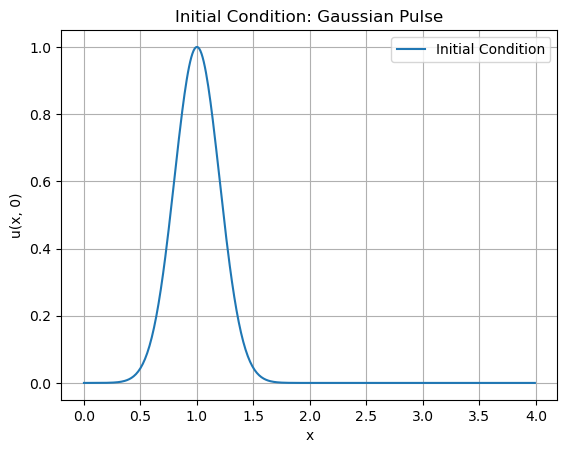

In [11]:
x0    = 1.0  # Initial position of the pulse
sigma = 0.2  # Width of the pulse (was 0.05 — too narrow, only 2.5 cells per sigma)

u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))
plt.plot(x, u0, label='Initial Condition')
plt.title('Initial Condition: Gaussian Pulse')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.legend()
plt.grid()
plt.show()


## Solve Viscous Burgers Equation

In [12]:
def upwind_viscous_burgers(u, dx, dt, alpha):
    u_left  = np.roll(u,  1)   # u_{i-1} for all i, wraps u[0] → u[-1] (periodic BC)
    u_right = np.roll(u, -1)   # u_{i+1} for all i, wraps u[-1] → u[0]  (periodic BC)

    # General upwind: use backward space when u > 0, forward space when u < 0
    conv = np.maximum(u, 0) * (u - u_left) + np.minimum(u, 0) * (u_right - u)

    # Diffusion term (central difference)
    diff = u_right - 2 * u + u_left

    return u - (dt / dx * conv) + (alpha * dt / dx**2 * diff)

u = np.copy(u0)
u_history = [u.copy()]

for n in range(nt):
    u = upwind_viscous_burgers(u, dx, dt, alpha)
    u_history.append(u.copy())

## Reynolds Number

In [13]:
# reynolds number
if alpha != 0:
    Re = u_max * L / alpha
    print(f"Reynolds number: Re = {Re:.2f}")
else:
    print("Reynolds number is undefined for alpha = 0")

Reynolds number: Re = 800.00


## Result

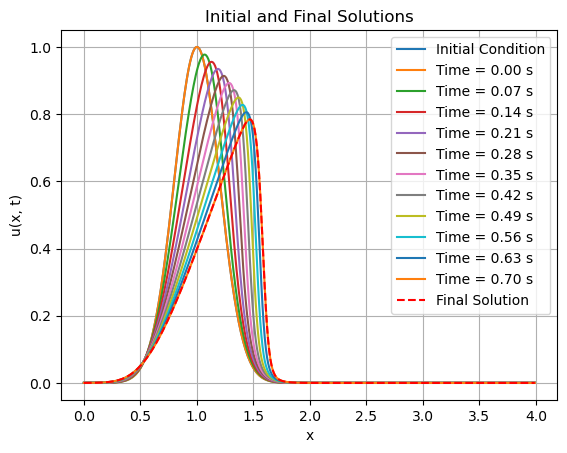

In [14]:

u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) # Initial condition
plt.plot(x, u0, label='Initial Condition')
for n in range(0, nt + 1, 20):
    plt.plot(x, u_history[n], label=f'Time = {n*dt:.2f} s')
plt.plot(x, u, label='Final Solution', linestyle='--', color='red')
plt.title('Initial and Final Solutions')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()


## Time of Shock

Inviscid shock time reference: t_s = 0.3300
Corresponding step index: 94


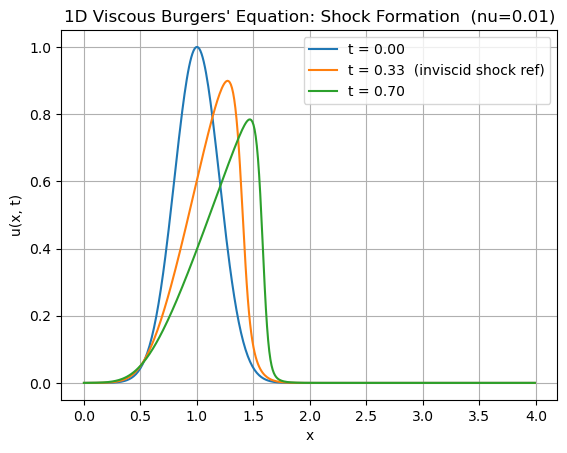

In [15]:
import numpy as np

# Shock time formula is from the INVISCID problem — in viscous Burgers,
# diffusion resists the shock so it forms later (or not at all at high nu).
# We use it here only as a reference time.
try:
    du0dx   = np.gradient(u0, dx)
    t_shock = -1.0 / np.min(du0dx)
    print(f"Inviscid shock time reference: t_s = {t_shock:.4f}")
    print(f"Corresponding step index: {int(t_shock / dt)}")

    plt.plot(x, u_history[0],               label='t = 0.00')
    plt.plot(x, u_history[int(t_shock/dt)], label=f't = {t_shock:.2f}  (inviscid shock ref)')
    plt.plot(x, u_history[-1],              label=f't = {T:.2f}')
    plt.title(f"1D Viscous Burgers' Equation: Shock Formation  (nu={alpha})")
    plt.xlabel('x')
    plt.ylabel('u(x, t)')
    plt.legend()
    plt.grid()
    plt.show()
except Exception as e:
    print("Error computing shock time:", e)

## Shock Thickness

In [16]:
# shock thickness estimate (not exact, just a reference scale)
shock_thickness = alpha / u_max
print(f"Estimated shock thickness (delta): {shock_thickness:.4f}")

Estimated shock thickness (delta): 0.0050
